In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn import metrics
from sklearn.kernel_ridge import KernelRidge
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_moons
from sklearn.datasets import make_circles

##Regression: Kernel Ridge Regression

In [ ]:
# Generate train and test set

n = 50

X_train = np.random.rand(n,1) * 8 - 4

def ground_truth(x):
    y = np.sin(x) + 2 * np.cos(4 * x) + 0.5 * np.sin(x + 1) # Combination of sinusioids
    return y.squeeze()
 
y_train = ground_truth(X_train) + np.random.rand(n)

X_test = np.linspace(-4, 4, 100).reshape(-1, 1)

y_test = ground_truth(X_test)

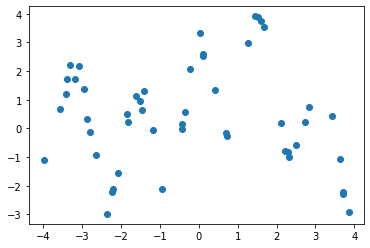

In [ ]:
# Plot the data

plt.scatter(X_train, y_train)

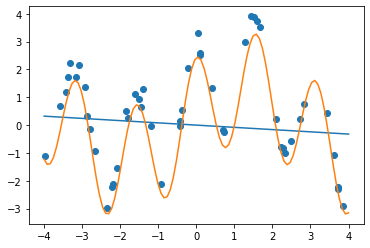

In [ ]:
# "Kernel" ridge regression with the linear kernel

krr = KernelRidge(alpha=0.01, kernel='linear')
krr.fit(X_train, y_train)
y_test_pred = krr.predict(X_test)

# Plot the training set, the predictor, and the ground trouth

plt.scatter(X_train, y_train)
plt.plot(X_test, y_test_pred)
plt.plot(X_test, y_test)

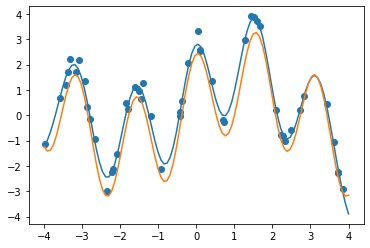

In [ ]:
# Kernel ridge regression with the RBF kernel

krr = KernelRidge(alpha=0.01, kernel='rbf')
krr.fit(X_train, y_train)
y_test_pred = krr.predict(X_test)

# Plot the training set, the predictor, and the ground trouth

plt.scatter(X_train, y_train)
plt.plot(X_test, y_test_pred)
plt.plot(X_test, y_test)

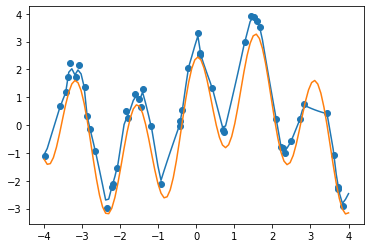

In [ ]:
# Let's try another kernel!
# Kernel ridge regression with the Laplacian kernel exp(-||x-y||)

krr = KernelRidge(alpha=0.01, kernel='laplacian')
krr.fit(X_train, y_train)
y_test_pred = krr.predict(X_test)

# Plot the training set, the predictor, and the ground trouth

plt.scatter(X_train, y_train)
plt.plot(X_test, y_test_pred)
plt.plot(X_test, y_test)

##Classification: Kernelized Logistic Regression

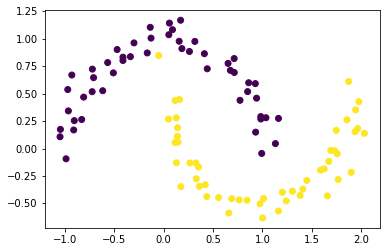

In [ ]:
# What about classification? Say we want to classify this dataset that is not linearly separable.
# Can we do it using Logistic regression... but with the kernel trick?

X_train, y_train = make_moons(n_samples=100, noise=0.1)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)

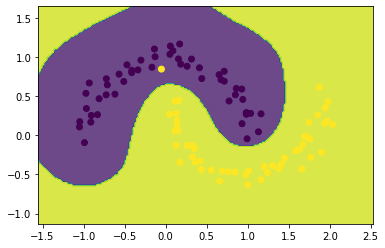

In [ ]:
# Kernelized Logistic regression with the RBF kernel

gamma = 10
K_trtr = metrics.pairwise.rbf_kernel(X_train, X_train, gamma=gamma)
klr = LogisticRegression()
klr.fit(K_trtr, y_train)

# Returns a vector of test points and the coordinate of the meshgrid

def test_meshgrid(X_train,):

    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    x_mesh, y_mesh = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    X_test = np.c_[x_mesh.ravel(), y_mesh.ravel()]

    return X_test, x_mesh, y_mesh

X_test, x_mesh, y_mesh = test_meshgrid(X_train,)

K_tetr = metrics.pairwise.rbf_kernel(X_test, X_train, gamma=gamma)
y_pred = klr.predict(K_tetr)
y_pred = y_pred.reshape(x_mesh.shape)
plt.contourf(x_mesh, y_mesh, y_pred, alpha=0.8)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)

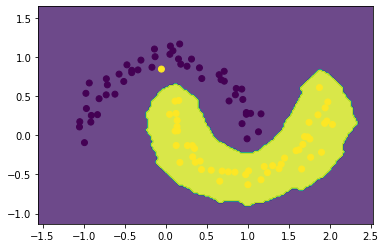

In [ ]:
# Kernelized Logistic regression with the Laplacian kernel

gamma = 10
K_trtr = metrics.pairwise.laplacian_kernel(X_train, X_train, gamma=gamma)
klr = LogisticRegression()
klr.fit(K_trtr, y_train)

def test_meshgrid(X_train,):

    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    x_mesh, y_mesh = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    X_test = np.c_[x_mesh.ravel(), y_mesh.ravel()]

    return X_test, x_mesh, y_mesh

X_test, x_mesh, y_mesh = test_meshgrid(X_train,)

K_tetr = metrics.pairwise.laplacian_kernel(X_test, X_train, gamma=gamma)
y_pred = klr.predict(K_tetr)
y_pred = y_pred.reshape(x_mesh.shape)
plt.contourf(x_mesh, y_mesh, y_pred, alpha=0.8)
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)